In [ ]:
# Q1. Load the dataset, PRSA_Data.csv, into memory.
import pandas as pd
df = pd.read_csv('PRSA_Data.csv')
df.head()

,No,date,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,1,2013-3-1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5
1,2,2013-3-1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7
2,3,2013-3-1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2
3,4,2013-3-1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0
4,5,2013-3-1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1


In [ ]:
# Q2. Clean the data and check missing values for this dataset.
df.dtypes

No         int64
date      object
hour       int64
PM2.5    float64
PM10     float64
SO2      float64
NO2      float64
CO       float64
O3       float64
TEMP     float64
PRES     float64
DEWP     float64
RAIN     float64
wd        object
WSPM     float64
dtype: object

In [ ]:
df.isnull().sum(axis = 0)

No          0
date        0
hour        0
PM2.5     774
PM10      582
SO2       628
NO2       667
CO       1521
O3        604
TEMP       53
PRES       50
DEWP       53
RAIN       51
wd        140
WSPM       43
dtype: int64

In [ ]:
df = df.dropna()
df

,No,date,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,1,2013-3-1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5
1,2,2013-3-1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7
2,3,2013-3-1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2
3,4,2013-3-1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0
4,5,2013-3-1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35057,35058,2017-2-28,17,18.0,61.0,6.0,29.0,400.0,51.0,14.7,1007.4,-12.6,0.0,WNW,4.2
35060,35061,2017-2-28,20,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1
35061,35062,2017-2-28,21,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5
35062,35063,2017-2-28,22,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4


In [ ]:
df.describe()

,No,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,32681.000000,32681.000000,32681.000000,32681.000000,32681.000000,32681.000000,32681.000000,32681.000000,32681.000000,32681.000000,32681.000000,32681.000000,32681.000000
mean,17876.569658,11.506992,70.312328,94.086402,15.061357,44.319035,1151.716441,57.424541,13.401677,1007.994009,1.135299,0.060736,1.865757
std,10010.547363,6.940587,70.955607,82.610340,21.057574,29.591375,1105.646637,53.792603,11.393462,10.177785,13.841226,0.765286,1.308218
min,1.000000,0.000000,3.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,9384.000000,6.000000,18.000000,33.000000,2.000000,22.000000,500.000000,15.000000,3.100000,999.500000,-10.600000,0.000000,1.000000
50%,17910.000000,11.000000,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.100000,1007.700000,1.100000,0.000000,1.500000
75%,26546.000000,18.000000,99.000000,130.000000,18.000000,61.000000,1400.000000,79.000000,23.100000,1016.300000,13.900000,0.000000,2.300000
max,35064.000000,23.000000,662.000000,992.000000,310.000000,208.000000,10000.000000,429.000000,41.400000,1036.500000,27.200000,52.100000,10.000000


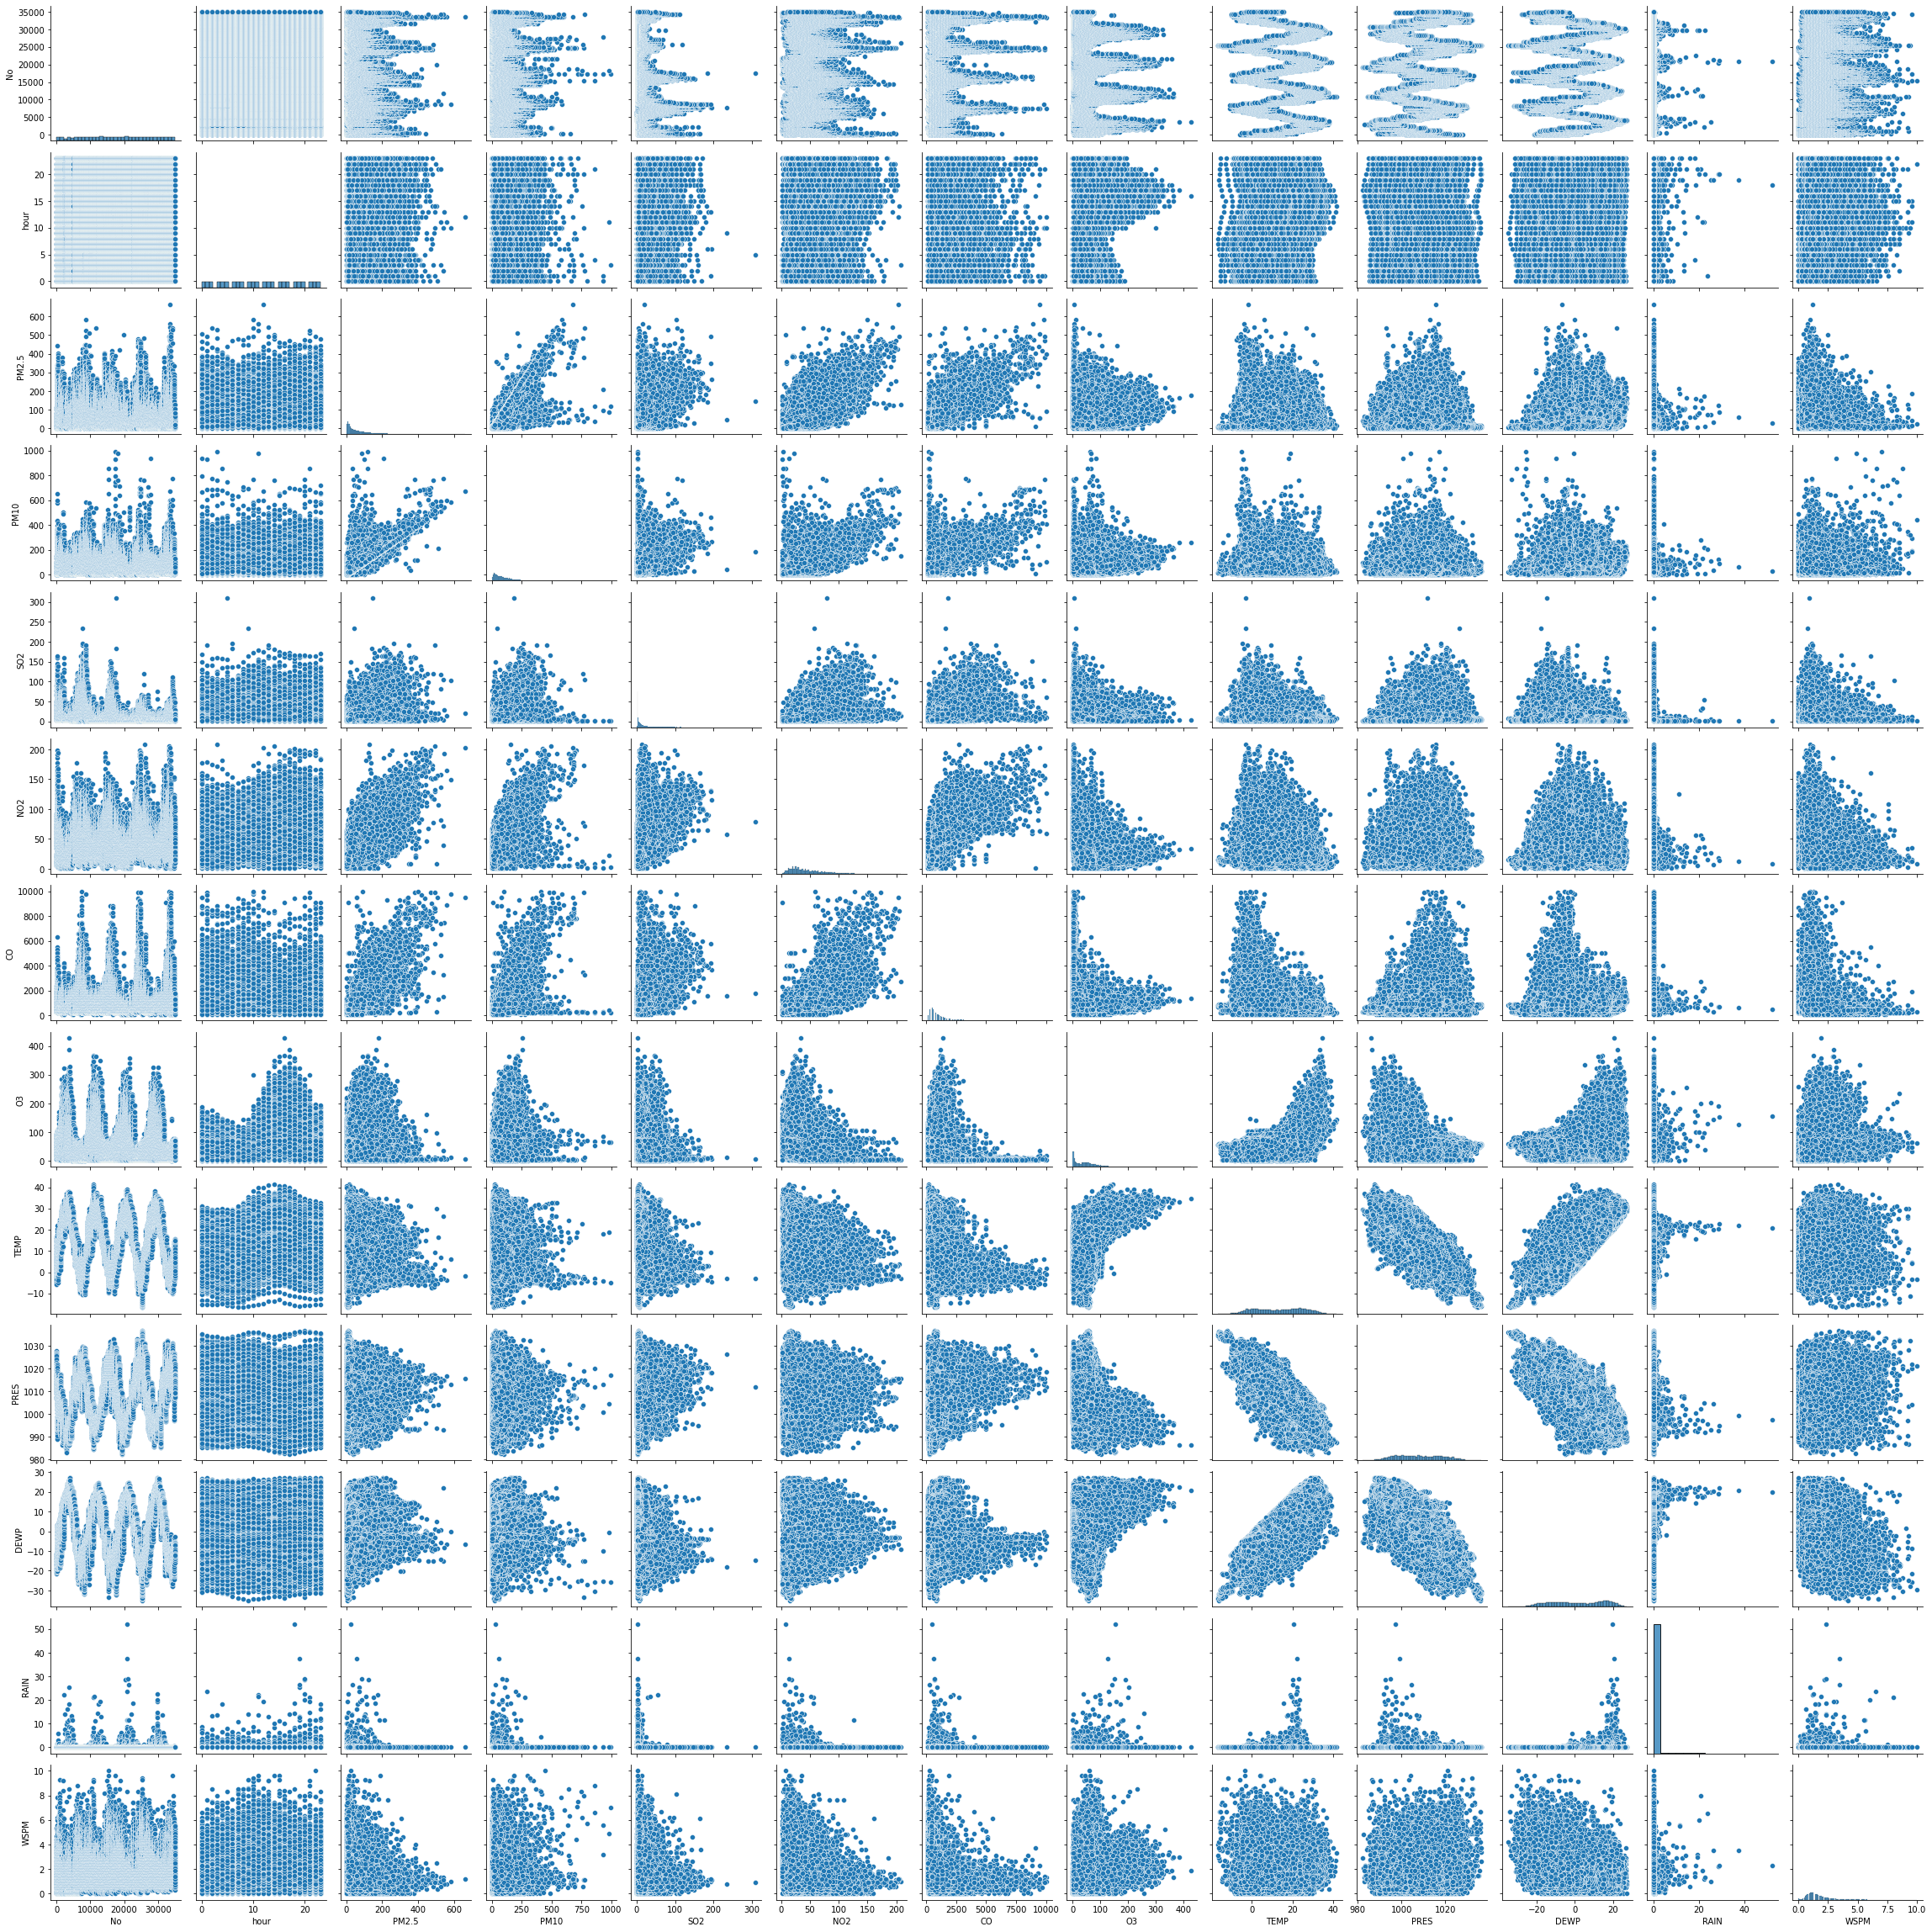

In [ ]:
import seaborn as sns
sns.pairplot(df)

In [ ]:
# Q3. Convert all categorical variables to numerical values.
df['wd'] = df['wd'].astype('category')
df['wd'] = df['wd'].cat.codes
df['wd'].unique()

array([ 0,  1,  5,  3,  6,  7,  4, 12, 11, 15,  2,  9,  8, 14, 10, 13],
      dtype=int8)

In [ ]:
# Q4. Perform feature engineering on the date feature.
df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek

df = df.drop('date',axis=1)

print(df.dtypes)
df.head()

No             int64
hour           int64
PM2.5        float64
PM10         float64
SO2          float64
NO2          float64
CO           float64
O3           float64
TEMP         float64
PRES         float64
DEWP         float64
RAIN         float64
wd              int8
WSPM         float64
year           int64
month          int64
dayofweek      int64
dtype: object


,No,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,year,month,dayofweek
0,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,0,0.5,2013,3,4
1,2,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,1,0.7,2013,3,4
2,3,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,1,0.2,2013,3,4
3,4,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,5,1.0,2013,3,4
4,5,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,3,2.1,2013,3,4


In [ ]:
# Q5. Split the data into 80% of training and 20% of the test dataset.
X = df.drop('PM2.5', axis=1)
y = df['PM2.5']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 2021)

In [ ]:
# Q6. Preprocess the data using the normalization method to convert all features into the range of [0,1]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Epoch 1/100
409/409 [==============================] - 1s 1ms/step - loss: 7013.2085 - val_loss: 4730.0327
Epoch 2/100
409/409 [==============================] - 0s 1ms/step - loss: 4006.0820 - val_loss: 3243.9312
Epoch 3/100
409/409 [==============================] - 0s 1ms/step - loss: 2212.7063 - val_loss: 1505.9653
Epoch 4/100
409/409 [==============================] - 0s 1ms/step - loss: 1259.8192 - val_loss: 1093.9469
Epoch 5/100
409/409 [==============================] - ETA: 0s - loss: 1039.05 - 0s 1ms/step - loss: 1029.5123 - val_loss: 951.3102
Epoch 6/100
409/409 [==============================] - 0s 1ms/step - loss: 927.4390 - val_loss: 872.7607
Epoch 7/100
409/409 [==============================] - 0s 1ms/step - loss: 865.4916 - val_loss: 815.9756
Epoch 8/100
409/409 [==============================] - 0s 1ms/step - loss: 817.6368 - val_loss: 770.1707
Epoch 9/100
409/409 [==============================] - 0s 1ms/step - loss: 780.7867 - val_loss: 736.9586
Epoch 10/100
409/409

409/409 [==============================] - 0s 1ms/step - loss: 565.4243 - val_loss: 543.4636
Epoch 79/100
409/409 [==============================] - 0s 1ms/step - loss: 562.7488 - val_loss: 531.5092
Epoch 80/100
409/409 [==============================] - 0s 1ms/step - loss: 561.6816 - val_loss: 534.2700
Epoch 81/100
409/409 [==============================] - 1s 1ms/step - loss: 559.9103 - val_loss: 530.8740
Epoch 82/100
409/409 [==============================] - 0s 1ms/step - loss: 557.1854 - val_loss: 526.9157
Epoch 83/100
409/409 [==============================] - 0s 1ms/step - loss: 554.9290 - val_loss: 524.6549
Epoch 84/100
409/409 [==============================] - 0s 1ms/step - loss: 552.7151 - val_loss: 529.7488
Epoch 85/100
409/409 [==============================] - 0s 1ms/step - loss: 550.4966 - val_loss: 520.1692
Epoch 86/100
409/409 [==============================] - 0s 1ms/step - loss: 547.8248 - val_loss: 518.3437
Epoch 87/100
409/409 [==============================] - 0s 

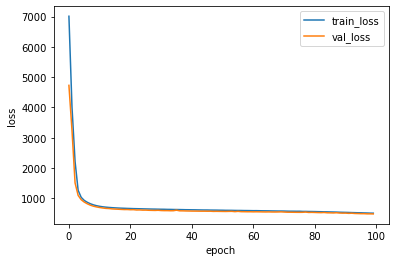

In [ ]:
# Q7. Build a neuron network with two hidden layers of 20 and 10 neurons to forecast PM2.5 using all other features and
# TensorFlow. Does it overfit or underfit the data? Please justify your answer.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential()
model.add(layers.Dense(20, activation='relu'))
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(x=X_train,y=y_train,batch_size=64,epochs=100,
          validation_data=(X_test,y_test), verbose= 1)
trainhist = pd.DataFrame(history.history)
trainhist['epoch'] = history.epoch

import matplotlib.pyplot as plt
sns.lineplot(x='epoch', y ='loss', data =trainhist)
sns.lineplot(x='epoch', y ='val_loss', data =trainhist)
plt.legend(labels=['train_loss', 'val_loss'])

# The model seems to be underfitting; the training and validation losses steadily decrease with a negative slope.

In [ ]:
# Q8. Tune the model using the following hyperparameters using keras-tuner:
    # First hidden layer with units between 20 and 50 with a step size of 5
    # Second hidden layer with units between 5 and 10 with a step size of 1
    # The dropout rate for both hidden layer is between 0.2 and 0.8 with a step size of 0.1
# Please recommend the optimal model and specify the hyperparameters.
import sys
if ( 'keras-tuner' not in sys.modules):
    !pip install -q -U keras-tuner
import keras_tuner as kt

from tensorflow.keras.layers import Dropout

def model_builder(hp):
    model = keras.Sequential()

    hp_units1 = hp.Int('units1', min_value = 20, max_value = 50, step = 5)
    model.add(layers.Dense(units = hp_units1, activation = 'relu'))
    hp_dropout1 = hp.Float('rate1', min_value = 0.2, max_value = 0.8, step = 0.1)
    model.add(Dropout(rate = hp_dropout1))

    hp_units2 = hp.Int('units2', min_value = 5, max_value = 10, step = 1)
    model.add(layers.Dense(units = hp_units2, activation = 'relu'))
    hp_dropout2 = hp.Float('rate2', min_value = 0.2, max_value = 0.8, step = 0.1)
    model.add(Dropout(rate = hp_dropout2))

    model.add(layers.Dense(1))

    model.compile(optimizer = 'adam', loss='mse')

    return model

You should consider upgrading via the 'C:\Users\srgra\anaconda3\python.exe -m pip install --upgrade pip' command.


In [ ]:
tuner = kt.Hyperband(model_builder, objective = 'val_loss', max_epochs = 100, directory = 'my_dir',
                     project_name = 'tuningclassification')

In [ ]:
import IPython
class ClearTrainingOutput(tf.keras.callbacks.Callback):
    def on_train_end(*args, **kwargs):
        IPython.display.clear_output(wait = True)

In [ ]:
tuner.search(X_train, y_train, epochs = 100, validation_data = (X_test,y_test), callbacks = [ClearTrainingOutput()])

Trial 254 Complete [00h 01m 40s]
val_loss: 606.010498046875

Best val_loss So Far: 468.6678161621094
Total elapsed time: 00h 46m 50s
INFO:tensorflow:Oracle triggered exit


In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]
print(f"""
The optimal number of units in the first layer =  {best_hps.get('units1')}.
The optimal droupout rate in the first layer = {best_hps.get('rate1')}.
The optimal number of units in the second layer =  {best_hps.get('units2')}.
The optimal droupout rate in the second layer = {best_hps.get('rate2')}.
""")


The optimal number of units in the first layer =  40. 
The optimal droupout rate in the first layer = 0.2.
The optimal number of units in the second layer =  10. 
The optimal droupout rate in the second layer = 0.30000000000000004.



epoch 0, loss = 9966.5596 and val_loss = 9940.6814
epoch 1, loss = 9868.7334 and val_loss = 9774.0075
epoch 2, loss = 9701.6865 and val_loss = 9500.7117
epoch 3, loss = 9427.7881 and val_loss = 9100.5862
epoch 4, loss = 9026.6758 and val_loss = 8562.3029
epoch 5, loss = 8486.8662 and val_loss = 7887.8601
epoch 6, loss = 7810.0879 and val_loss = 7102.5559
epoch 7, loss = 7021.2495 and val_loss = 6269.4369
epoch 8, loss = 6182.8120 and val_loss = 5510.0709
epoch 9, loss = 5415.5137 and val_loss = 5027.6066
epoch 10, loss = 4921.4976 and val_loss = 5075.3329
epoch 11, loss = 4953.7935 and val_loss = 5608.0635
epoch 12, loss = 5471.5137 and val_loss = 5953.4586
epoch 13, loss = 5810.7310 and val_loss = 5812.8009
epoch 14, loss = 5673.2798 and val_loss = 5404.2160
epoch 15, loss = 5273.3838 and val_loss = 4991.0403
epoch 16, loss = 4870.8970 and val_loss = 4720.9441
epoch 17, loss = 4611.1816 and val_loss = 4619.2432
epoch 18, loss = 4518.3286 and val_loss = 4635.5544
epoch 19, loss = 4541.

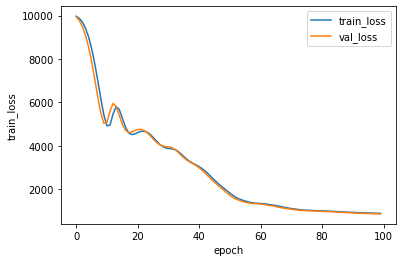

In [ ]:
# Q9. Build a neuron network with two hidden layers of 20 and 10 neurons to forecast PM2.5 using all other features and PyTorch.
# Does it overfit or underfit the data? Please justify your answer.
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

X_train = torch.tensor(X_train.astype(np.float32))
y_train = torch.tensor(y_train.values.astype(np.float32).reshape(-1,1))

input_size = X_train.shape[1]
output_size = y_train.shape[1]
hidden_size = [20, 10]

X_test = torch.from_numpy(X_test.astype(np.float32))

class LinearRegressionModel(torch.nn.Module):
    def __init__(self, input_size,  hidden_size, output_size):
        super(LinearRegressionModel, self).__init__()
        self.hidden1 = torch.nn.Linear(input_size, hidden_size[0])
        self.hidden2 = torch.nn.Linear(hidden_size[0], hidden_size[1])
        self.predict = torch.nn.Linear(hidden_size[1], output_size)
    def forward(self, x):
        x = F.relu(self.hidden1(x))
        x = F.relu(self.hidden2(x))
        y_pred = self.predict(x)
        return y_pred

model = LinearRegressionModel(input_size, hidden_size,  output_size)
l = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

num_epochs = 100
train_loss = [None]*num_epochs
valadition_loss = [None]*num_epochs

from sklearn.metrics import mean_squared_error

for epoch in range(num_epochs):
    y_pred = model(X_train.requires_grad_())
    loss= l(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    y_pred = model(X_test).detach().numpy()
    val_loss = mean_squared_error(y_test,y_pred)
    train_loss[epoch] = loss.item()
    valadition_loss[epoch] = val_loss
    print('epoch {0}, loss = {1:.4f} and val_loss = {2:.4f}'.format(epoch, loss.item(), val_loss))

trainhist = pd.DataFrame({'train_loss': train_loss, 'val_loss': valadition_loss, 'epoch':np.arange(num_epochs)})
trainhist.tail()

import matplotlib.pyplot as plt
sns.lineplot(x='epoch', y ='train_loss', data =trainhist)
sns.lineplot(x='epoch', y ='val_loss', data =trainhist)
plt.legend(labels=['train_loss', 'val_loss'])
# The model seems to be underfitting; the training and validation losses steadily decrease (for the most part) with a negative
# slope.